In [1]:
!pip install -U transformers scikit-learn scipy matplotlib imbalanced-learn nlpaug nltk wordnet scikit-multilearn seaborn torch torchvision optuna seaborn GPUtil psutil

Requirement already up-to-date: transformers in /home/hmohammadi/.local/lib/python3.8/site-packages (4.32.1)
Requirement already up-to-date: scikit-learn in /home/hmohammadi/.local/lib/python3.8/site-packages (1.3.0)
Requirement already up-to-date: scipy in /home/hmohammadi/.local/lib/python3.8/site-packages (1.10.1)
Requirement already up-to-date: matplotlib in /home/hmohammadi/.local/lib/python3.8/site-packages (3.7.2)
Requirement already up-to-date: imbalanced-learn in /home/hmohammadi/.local/lib/python3.8/site-packages (0.11.0)
Requirement already up-to-date: nlpaug in /home/hmohammadi/.local/lib/python3.8/site-packages (1.1.11)
Requirement already up-to-date: nltk in /home/hmohammadi/.local/lib/python3.8/site-packages (3.8.1)
Requirement already up-to-date: wordnet in /home/hmohammadi/.local/lib/python3.8/site-packages (0.0.1b2)
Requirement already up-to-date: scikit-multilearn in /home/hmohammadi/.local/lib/python3.8/site-packages (0.2.0)
Requirement already up-to-date: seaborn i

In [2]:
# Clear GPU cache memory

import torch
import time
import psutil
import GPUtil as GPU
#torch.cuda.empty_cache()
print('*********************** Part 1 ***********************')

# Define a function to print system usage
def print_system_usage():
    print(f"CPU Usage: {psutil.cpu_percent()}%")
    print(f"RAM Usage: {psutil.virtual_memory().percent}%")
    GPUs = GPU.getGPUs()
    for i, gpu in enumerate(GPUs):
        print(f"GPU {i} Usage: {gpu.load*100:.1f}%")
    
# Time to predict runtime
#start_time = time.time()

print_system_usage()
print('*********************** Part 2 ***********************')
# 1. Install packages
#pip install -U transformers scikit-learn scipy matplotlib imbalanced-learn nlpaug nltk wordnet scikit-multilearn seaborn torch torchvision optuna seaborn

# 2. Import libraries

# General libraries
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Sklearn libraries
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, 
    label_ranking_average_precision_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

# Skmultilearn
from skmultilearn.model_selection import IterativeStratification

# Imbalanced-learn
from imblearn.over_sampling import RandomOverSampler, SMOTE

# NLTK libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

# Transformers
from transformers import (
    BertTokenizer, BertModel,
    DistilBertModel, BertTokenizerFast,
    XLMRobertaTokenizerFast, 
    GPT2Tokenizer
)

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

# Nlpaug libraries
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
from nlpaug.augmenter.char import RandomCharAug
from nlpaug.augmenter.word import SynonymAug, RandomWordAug


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import torch.optim as optim  

from transformers import XLMRobertaModel


import time
import psutil
import os

import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel, XLMRobertaTokenizer, XLMRobertaModel, DistilBertTokenizer, DistilBertModel
from torch.utils.data import DataLoader
import optuna

from transformers import BertTokenizer, BertModel

#torch.cuda.empty_cache()
torch.cuda.is_available()

*********************** Part 1 ***********************
CPU Usage: 1.2%
RAM Usage: 1.4%
GPU 0 Usage: 0.0%
GPU 1 Usage: 0.0%
*********************** Part 2 ***********************


[nltk_data] Downloading package wordnet to
[nltk_data]     /home/hmohammadi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/hmohammadi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/hmohammadi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
/home/hmohammadi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
import torch

# Current memory allocated
current_memory_allocated = torch.cuda.memory_allocated() 

# Peak (max) memory allocated
peak_memory_allocated = torch.cuda.max_memory_allocated() 

print(f"Current memory (in bytes): {current_memory_allocated}")
print(f"Peak memory (in bytes): {peak_memory_allocated}")

Current memory (in bytes): 0
Peak memory (in bytes): 0


In [4]:
# Load main data
files = ['dev_en_news', 'dev_en_reviews', 'dev_en_twitter', 'dev_nl_news', 'dev_nl_reviews', 'dev_nl_twitter']
df_list = []

for file in files:
    domain, lang = file.split("_")[1:3]
    temp_df = pd.read_csv(f'{file}.csv')
    temp_df['domain'] = lang
    temp_df['lan'] = domain
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.rename(columns={"Unnamed: 0": "id"})
df['source']='CLIN33'
df['label1'] = ['generated' if label == 1 else 'human' for label in df['label']]
df.reset_index()
df

,id,text,label,domain,lan,source,label1
0,95,Mars and Venus still may have their difference...,0,news,en,CLIN33,human
1,15,The Russian oil giant Yukos and the government...,0,news,en,CLIN33,human
2,30,"Since the end of World War II, Democrats and R...",0,news,en,CLIN33,human
3,58,"Senator Harry Reid of Nevada, the Democratic l...",1,news,en,CLIN33,generated
4,28,The semiconductor industry is set to break rec...,1,news,en,CLIN33,generated
...,...,...,...,...,...,...,...
1195,6,Tip: Verander #vaccinatiedwang in #zelfbeschik...,1,twitter,nl,CLIN33,generated
1196,14,"Wij houden u in lockdown, want we moeten koste...",0,twitter,nl,CLIN33,human
1197,92,"dus iedereen heeft corona, tot het tegendeel b...",0,twitter,nl,CLIN33,human
1198,79,Waarom moeten we dit accepteren? 😡 #vaccinatie...,1,twitter,nl,CLIN33,generated


In [5]:
#Part 3
sample_size=1000
num_labels=1
max_length=256 #512
MAX_LENGTH = 128 #256
num_folds = 2

#batch_size_values=[32]
batch_size_values=[16, 32,64]

# Set parameters
num_epochs = 4
batch_size = 64
learning_rate = 3e-05

# Function to preprocess text
def preprocess_text(text):
    # Lowercase the text
    text = text.lower()
    # Remove URLs, special characters and punctuation
    text = re.sub(r'(https?://\S+|www\.\S+)', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # Tokenize the text
    words = word_tokenize(text)
    
    # Lemmatize words using WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(lemmatized_words)

# Create a dataframe of en_train and their labels


# Preprocess the text in the additional dataset
df['text'] = df['text'].apply(preprocess_text)

# Concatenate the datasets based on id, text, label 1, and lang, source
#df = pd.concat([df, additional_df], ignore_index=True)
#df=df.iloc[0:sample_size,:]

print('*********************** Part 4 ***********************')

*********************** Part 4 ***********************


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Sample data frame (use your actual dataframe)
df = pd.read_csv('df.csv')

# Combine domain, lan, and label into a single strata column
df['strata'] = df['domain'] + "_" + df['lan'] + "_" + df['label'].astype(str)

# Use train_test_split to create train and test datasets with stratification
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['strata'], random_state=42)

# Drop the strata column as it's no longer needed
train_df = train_df.drop(columns=['strata'])
test_df = test_df.drop(columns=['strata'])

# Verify the distribution in test set
print(test_df['domain'].value_counts())
print(test_df['lan'].value_counts())
print(test_df['label'].value_counts())

domain
reviews    40
news       40
twitter    40
Name: count, dtype: int64
lan
en    60
nl    60
Name: count, dtype: int64
label
1    60
0    60
Name: count, dtype: int64


In [8]:
import pandas as pd

train_df_augmented = pd.read_csv('augmented_data.csv')

train_df_augmented.reset_index()
train_df_augmented

,id,text,label,label1,Domain,lan,augmentation_type
0,24,van onze redactrice kim de rijck om na te gaan...,0,human,news,nl,original
1,24,['van onze redactrice kim de rijck om na te ga...,0,human,news,nl,synonym
2,24,['van onze redactrice kim de rijck om na te ga...,0,human,news,nl,swap
3,24,['van onze redactrice kim de rijck om na te ga...,0,human,news,nl,insert
4,24,['van onze redactrice kim de rijck om na te ga...,0,human,news,nl,substitute
...,...,...,...,...,...,...,...
9715,55,['i wanted morocco to get third place at the _...,0,human,twitter,en,substitute
9716,55,['i wand morocco to get tid pae at the world c...,0,human,twitter,en,delete
9717,55,['it wanted morocco to get third place at yhe ...,0,human,twitter,en,spelling
9718,55,I wanted morocco to get third place on the wor...,0,human,twitter,en,back_translation_en_nl


In [9]:
test_df=pd.read_csv('test_df.csv')
test_df

,id,text,label,domain,lan,source,label1
0,49,let me tell you this thing is not worth the pr...,1,reviews,en,CLIN33,generated
1,45,vandaag is een dag die voor veel mensen een bi...,1,news,nl,CLIN33,generated
2,20,al zij belgi zo lief hebben moeten ze nu beweg...,0,news,nl,CLIN33,human
3,85,the coast guard is currently searching for a m...,1,news,en,CLIN33,generated
4,67,wolf whistling and cat calling is sexual haras...,0,twitter,en,CLIN33,human
...,...,...,...,...,...,...,...
115,6,using a laptop while traveling can be convenie...,1,news,en,CLIN33,generated
116,65,microsoft announced yesterday that it ha hired...,1,news,en,CLIN33,generated
117,36,the interpublic group of company one of the wo...,1,news,en,CLIN33,generated
118,29,i bought these glove hoping they would keep my...,1,reviews,en,CLIN33,generated


In [10]:
#Data set 1()
#Part 9

AuTexTification_train = pd.read_csv('train.tsv', sep='\t')
AuTexTification_test = pd.read_csv('test.tsv', sep='\t')
#AuTexTification=pd.concat([AuTexTification_train, AuTexTification_test], ignore_index=True)

AuTexTification_train=AuTexTification_train[['id', 'text', 'label']]
AuTexTification_train = AuTexTification_train.rename(columns={'label': 'label1'})
AuTexTification_train['label'] = [1 if label == 'generated' else 0 for label in AuTexTification_train['label1']]

AuTexTification_test=AuTexTification_test[['id', 'text', 'label']]
AuTexTification_test = AuTexTification_test.rename(columns={'label': 'label1'})
AuTexTification_test['label'] = [1 if label == 'generated' else 0 for label in AuTexTification_test['label1']]

# Preprocess the text in the additional dataset
AuTexTification_train['text'] = AuTexTification_train['text'].apply(preprocess_text)
AuTexTification_test['text'] = AuTexTification_test['text'].apply(preprocess_text)

In [11]:
AuTexTification_test

,id,text,label1,label
0,15725,it ha remained one of my favorite countryswing...,human,0
1,17108,even with very light use hard to get motivated...,human,0
2,383,she died in 2015 at age 93 she is survived by ...,generated,1
3,7809,londonderry crown court heard how heaney false...,human,0
4,6215,will genia lachie turner and berrick barnes ex...,human,0
...,...,...,...,...
21827,11964,however it still ha some great song that you c...,generated,1
21828,21575,i bought the product because i wanted to see i...,generated,1
21829,5390,this will make it easier for u to plan adequat...,human,0
21830,860,the plan include new emergency department a sp...,generated,1


In [12]:
#Final Datasets

#data1_train=AuTexTification_train
#data1_valid=AuTexTification_test
#data2_train=train_df_augmented
#data_test=test_df

#train=AuTexTification_train
train=train_df_augmented

#train=train.iloc[0:1000,:]

labels_as_binary = [1 if label == 'generated' else 0 for label in train['label1']]
train.drop(['label1', 'Domain','lan', 'augmentation_type'], axis='columns', inplace=True)

#train.drop(['label1'], axis='columns', inplace=True)

#test=AuTexTification_test
test=test_df

labels_as_binary1 = [1 if label == 'generated' else 0 for label in test['label1']]
#test.drop(['label1'], axis='columns', inplace=True)
test.drop(['label1', 'domain', 'lan', 'source'], axis='columns', inplace=True)


test

,id,text,label
0,49,let me tell you this thing is not worth the pr...,1
1,45,vandaag is een dag die voor veel mensen een bi...,1
2,20,al zij belgi zo lief hebben moeten ze nu beweg...,0
3,85,the coast guard is currently searching for a m...,1
4,67,wolf whistling and cat calling is sexual haras...,0
...,...,...,...
115,6,using a laptop while traveling can be convenie...,1
116,65,microsoft announced yesterday that it ha hired...,1
117,36,the interpublic group of company one of the wo...,1
118,29,i bought these glove hoping they would keep my...,1


In [13]:
train

,id,text,label
0,24,van onze redactrice kim de rijck om na te gaan...,0
1,24,['van onze redactrice kim de rijck om na te ga...,0
2,24,['van onze redactrice kim de rijck om na te ga...,0
3,24,['van onze redactrice kim de rijck om na te ga...,0
4,24,['van onze redactrice kim de rijck om na te ga...,0
...,...,...,...
9715,55,['i wanted morocco to get third place at the _...,0
9716,55,['i wand morocco to get tid pae at the world c...,0
9717,55,['it wanted morocco to get third place at yhe ...,0
9718,55,I wanted morocco to get third place on the wor...,0


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Part 5
#filtered_train_df_augmented = train_df_augmented[~((train_df_augmented['label'] == 1) & (train_df_augmented['augmentation_type'] != 'original'))]
#train_df_augmented=filtered_train_df_augmented

#labels_as_binary = [1 if label == 'generated' else 0 for label in train_df_augmented['label1']]

from sklearn.model_selection import StratifiedKFold

start_time = time.time()

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(train, labels_as_binary, test_size=0.1, stratify=labels_as_binary, random_state=42)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=[0, 1], y=y_train)
class_weights = torch.tensor(class_weights).float().to(device)

def split_data_for_fold(fold_num, n_splits=5, data=X_train, labels=y_train):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_data = list(skf.split(data, labels))
    
    train_index, test_index = fold_data[fold_num]
    X_train_fold, X_test_fold = data.iloc[train_index], data.iloc[test_index]
    y_train_fold, y_test_fold = [labels[i] for i in train_index], [labels[i] for i in test_index]
    
    return X_train_fold, X_test_fold, y_train_fold, y_test_fold

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
train_encodings = tokenizer(X_train['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
test_encodings = tokenizer(X_test['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")

# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Creating the datasets
train_dataset = CustomDataset(train_encodings, y_train)
test_dataset = CustomDataset(test_encodings, y_test)

# Increase batch size if your GPU memory allows
BATCH_SIZE = 128

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print('*********************** Part 6 ***********************')

#Part 6
device = torch.device("cuda" if torch.cuda.is_available() else "CPU")

warmup_steps = 200
total_steps = num_epochs * (len(train_df_augmented['id']) // 16)

# Define a learning rate scheduler
def create_scheduler(learning_rate, warmup_steps, total_steps):
    def lr_lambda(epoch):
        step = epoch * (len(train_df_augmented['id']) // 16)
        if step < warmup_steps:
            return learning_rate * (step / warmup_steps)
        return learning_rate * (0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps))))
    return lr_lambda

# Dynamic adjustment of learning rate
from transformers import get_linear_schedule_with_warmup

elapsed_time = time.time() - start_time
print(f"Estimated runtime: {elapsed_time:.2f} seconds")

print_system_usage()

*********************** Part 6 ***********************
Estimated runtime: 31.12 seconds
CPU Usage: 1.8%
RAM Usage: 2.2%
GPU 0 Usage: 0.0%
GPU 1 Usage: 0.0%


In [15]:
#Part 7

X=train
y=labels_as_binary

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
X_encodings = tokenizer(X['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")

# Creating the datasets
X_dataset = CustomDataset(X_encodings, y)

# Increase batch size if your GPU memory allows
BATCH_SIZE = 128

# Dataloaders
X_loader = DataLoader(X_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

In [16]:
#part 8

X_dev=test
y_dev=labels_as_binary1

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
dev_encodings= tokenizer(X_dev['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")

# Creating the datasets
dev_dataset = CustomDataset(dev_encodings, y_dev)

# Increase batch size if your GPU memory allows
BATCH_SIZE = 128

# Dataloaders
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Some weights of BertModel were not initialized from the model checkpoint at wietsedv/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at wietsedv/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it i

Epoch [1/10], Train Loss: 0.0123, Test Loss: 0.7060, Test Accuracy: 0.5132
Estimated time left for training: 5448.54 seconds
RAM Usage: 16.1%, CPU Usage: 25.4%, GPU Memory Used: 10.391855104 GB


/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy const

Epoch [2/10], Train Loss: 0.0120, Test Loss: 0.6895, Test Accuracy: 0.5126
Estimated time left for training: 4540.00 seconds
RAM Usage: 16.0%, CPU Usage: 26.8%, GPU Memory Used: 10.389823488 GB


/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy const

...

Epoch [9/10], Train Loss: 0.0064, Test Loss: 0.8835, Test Accuracy: 0.5760
Estimated time left for training: 571.74 seconds
RAM Usage: 16.0%, CPU Usage: 26.0%, GPU Memory Used: 10.389823488 GB


/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy const

Epoch [10/10], Train Loss: 0.0053, Test Loss: 1.1752, Test Accuracy: 0.6124
Estimated time left for training: 0.00 seconds
RAM Usage: 16.1%, CPU Usage: 26.9%, GPU Memory Used: 10.389823488 GB


Some weights of BertModel were not initialized from the model checkpoint at wietsedv/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertModel were not initialized from the model checkpoint at wietsedv/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_8689/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Best Model Performance - Accuracy: 0.6124
F1 Score: 0.5652
Precision: 0.6749
Recall: 0.6046


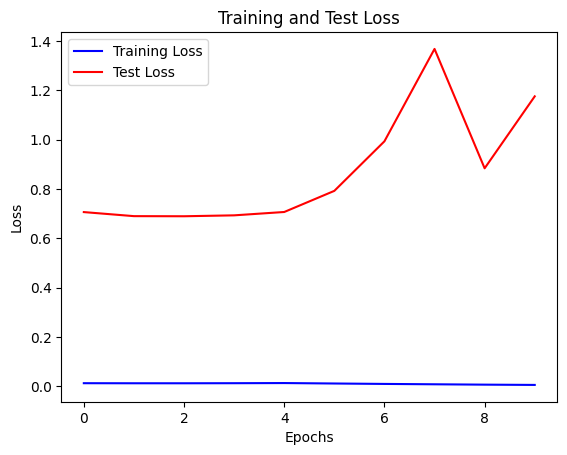

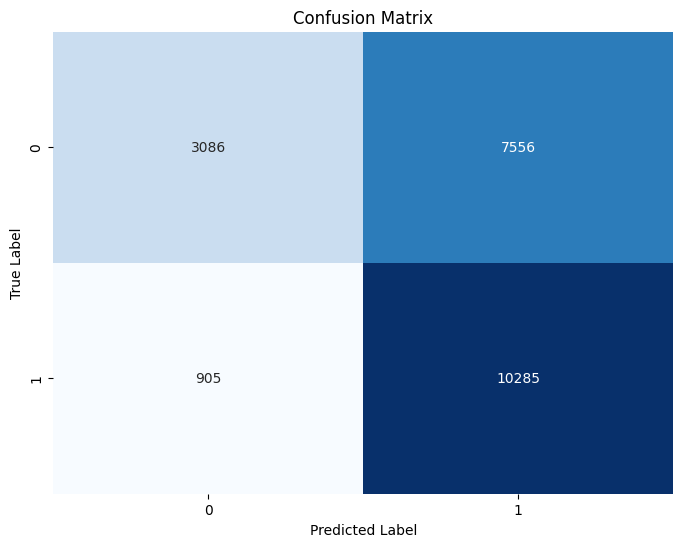

In [17]:
##with additional data + All type

import torch
import psutil
import time
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.cuda.amp as amp

best_params={'learning_rate': 5.1861920141671966e-05, 'batch_size': 102, 'weight_decay': 3.615286714186411e-05}
GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs

# Clear GPU cache memory
#torch.cuda.empty_cache()

# System and GPU Monitoring Functions
def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

# Evaluate Model Function
def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

# Hyperparameters and Training Setup
# best_params = study.best_params
learning_rate = best_params["learning_rate"]
#batch_size = best_params["batch_size"] * 1
batch_size = 52
num_epochs = 10
model = CustomBERTModel(num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(X_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
scaler = amp.GradScaler()
train_losses = []
test_losses = []  # Storing test losses

# Early stopping parameters
patience = 3
best_test_acc = 0.0
epochs_without_improvement = 0

# Training Loop with Gradient Accumulation
model.train()
start_time = time.time()

# Additional variables for gradient accumulation
accumulated_loss = 0.0
gradient_step_counter = 0  # To keep track of when to perform an optimization step

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    running_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        
        with amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        # Change from immediate backward pass to accumulating gradients
        scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
        accumulated_loss += loss.item()

        # Perform an optimization step once every GRADIENT_ACCUMULATION_STEPS
        gradient_step_counter += 1
        if gradient_step_counter % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            running_loss += accumulated_loss  # We add the accumulated loss here
            accumulated_loss = 0.0
    
    train_loss = running_loss / len(X_dataset)
    train_losses.append(train_loss)

    # Evaluate on test set after each epoch
    test_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    test_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader, criterion)
    test_losses.append(test_loss)  # Storing test loss

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    # Early stopping logic
    if acc > best_test_acc:
        best_test_acc = acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
        # Saving model weights after training
        torch.save(model.bert_model.state_dict(), "bert_model_weights.pth")
        torch.save(model.xlm_roberta_model.state_dict(), "xlm_roberta_model_weights.pth")
        torch.save(model.distilbert_model.state_dict(), "distilbert_model_weights.pth")
        #torch.save(model.bertje_model.state_dict(), "bertje_model_weights.pth")
        #torch.save(model.roberta_model.state_dict(), "roberta_model_weights.pth")
        #torch.save(model.bertdutch_model.state_dict(), "bertdutch_model_weights.pth")
        #torch.save(model.bertnl_model.state_dict(), "bertnl_model_weights.pth") 
     
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == patience:
            print("Early stopping due to no improvement!")
            break

    epoch_duration = time.time() - epoch_start_time
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_time_left = epoch_duration * remaining_epochs
    print(f"Estimated time left for training: {estimated_time_left:.2f} seconds")

    ram_percent, cpu_percent = get_system_usage()
    gpu_memory = get_gpu_memory()
    print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

# Load Best Model
loaded_model = CustomBERTModel(num_labels=2).to(device)
loaded_model.load_state_dict(torch.load("best_model.pth"))
loaded_model.eval()

# Evaluate Best Model
f1, acc, precision, recall, true_labels, preds = evaluate_model(loaded_model, test_loader, criterion)[-6:]

print(f"Best Model Performance - Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Plot Training and Test Loss
plt.plot(train_losses, label="Training Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [16]:
#combined model

In [ ]:
import torch
import psutil
import time
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.cuda.amp as amp

best_params = {'learning_rate': 5.1861920141671966e-05, 'batch_size': 102, 'weight_decay': 3.615286714186411e-05}
GRADIENT_ACCUMULATION_STEPS = 2  

def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

learning_rate = best_params["learning_rate"]
batch_size = 52
num_epochs = 10
model = CombinedModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(X_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
scaler = amp.GradScaler()

train_losses = []
test_losses = []

patience = 3
best_test_acc = 0.0
epochs_without_improvement = 0

model.train()
start_time = time.time()

accumulated_loss = 0.0
gradient_step_counter = 0

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    running_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        
        with amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
        accumulated_loss += loss.item()
        gradient_step_counter += 1
        if gradient_step_counter % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            running_loss += accumulated_loss
            accumulated_loss = 0.0
    
    train_loss = running_loss / len(X_dataset)
    train_losses.append(train_loss)

    test_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    test_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader, criterion)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    if acc > best_test_acc:
        best_test_acc = acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "combined_model_weights.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == patience:
            print("Early stopping due to no improvement!")
            break

    epoch_duration = time.time() - epoch_start_time
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_time_left = epoch_duration * remaining_epochs
    print(f"Estimated time left for training: {estimated_time_left:.2f} seconds")

    ram_percent, cpu_percent = get_system_usage()
    gpu_memory = get_gpu_memory()
    print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

# Load Best Model
loaded_model = CombinedModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
loaded_model.load_state_dict(torch.load("combined_model_weights.pth"))
loaded_model.eval()

f1, acc, precision, recall, true_labels, preds = evaluate_model(loaded_model, test_loader, criterion)[-6:]

print(f"Best Model Performance - Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Plot Training and Test Loss
plt.plot(train_losses, label="Training Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

Epoch [1/10], Train Loss: 0.0133, Test Loss: 0.6936, Test Accuracy: 0.5000
Estimated time left for training: 1489.09 seconds
RAM Usage: 14.6%, CPU Usage: 23.5%, GPU Memory Used: 11.948261376 GB


/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

Epoch [2/10], Train Loss: 0.0133, Test Loss: 0.6931, Test Accuracy: 0.5333
Estimated time left for training: 1215.04 seconds
RAM Usage: 14.7%, CPU Usage: 25.6%, GPU Memory Used: 11.93017344 GB


/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

...

/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

Epoch [4/10], Train Loss: 0.0110, Test Loss: 0.6893, Test Accuracy: 0.5833
Estimated time left for training: 876.35 seconds
RAM Usage: 14.6%, CPU Usage: 26.2%, GPU Memory Used: 11.93017344 GB


/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

Epoch [5/10], Train Loss: 0.0098, Test Loss: 0.8031, Test Accuracy: 0.6167
Estimated time left for training: 758.49 seconds
RAM Usage: 14.6%, CPU Usage: 26.6%, GPU Memory Used: 11.93017344 GB


/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_117123/4084739685.py:43: UserWarning: To co

In [ ]:
#section 2

In [17]:
print ('********************************************** CLASSIFICATION METHOD **********************************************')

********************************************** CLASSIFICATION METHOD **********************************************


In [18]:
#Classification problem
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)

In [19]:
# Evaluate Model Function
def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

In [ ]:
GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs

def objective(trial):
    
    # Get data for a specific fold - assuming trial.number returns current trial number
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = split_data_for_fold(trial.number % 5)  # Here we assumed 5 folds

    # Tokenization
    tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
    train_encodings_fold = tokenizer(X_train_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    test_encodings_fold = tokenizer(X_test_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    
    # Hyperparameters 
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_int("batch_size", 64, 128, log=True)
    num_epochs = 3

    # Model, optimizer, criterion
    model = CustomBERTModel(num_labels=2).to(device)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)  # Hyperparameter search for weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # Adding weight decay here
    #optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    #criterion = nn.CrossEntropyLoss()
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Creating the datasets
    train_dataset_fold = CustomDataset(train_encodings_fold, y_train_fold)
    test_dataset_fold = CustomDataset(test_encodings_fold, y_test_fold)
    
    # DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    # Use this test_loader if needed in validation
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # DataLoader
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for batch_idx, batch in enumerate(train_loader_fold):
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and gradient accumulation
            loss.backward()
            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
                
            running_loss += loss.item()
            
            # Clean up
            del inputs, labels, outputs
            torch.cuda.empty_cache()
            
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        # Estimation of finishing time
        remaining_epochs = num_epochs - (epoch + 1)
        estimated_time_left = epoch_duration * remaining_epochs
        print(f"Epoch {epoch + 1}/{num_epochs} - Estimated time left for training: {estimated_time_left:.2f} seconds")

        # Monitor RAM, CPU, and GPU usage
        ram_percent, cpu_percent = get_system_usage()
        gpu_memory = get_gpu_memory()
        print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Total training time: {training_time:.2f} seconds")
    
    # Evaluate the model
    #f1, acc, precision, recall, true_labels, preds  = evaluate_model(model, test_loader_fold, criterion)
    average_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader_fold, criterion)

    print(f"F1 Score (Macro): {f1:.4f}, Accuracy: {acc:.4f}, Precision (Macro): {precision:.4f}, Recall (Macro): {recall:.4f}")

    return f1  # Return F1-score for Optuna optimization. Adjust if needed.

study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=3)
study.optimize(objective, n_trials=15)  # For instance, if using 5 folds, you can do 3 trials for each fold, totaling 15 trials.

all_f1_scores = [trial.value for trial in study.trials]
average_f1_score = sum(all_f1_scores) / len(all_f1_scores)
print(f"Average F1 Score (Macro) over {len(all_f1_scores)} folds: {average_f1_score:.4f}")

print(study.best_params)

[I 2023-09-03 21:21:23,638] A new study created in memory with name: no-name-cf51329e-c663-4aac-96e0-c207c3d0a114
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.weight', 'clas

Epoch 1/3 - Estimated time left for training: 1502.01 seconds
RAM Usage: 9.0%, CPU Usage: 15.5%, GPU Memory Used: 16.600899072 GB
Epoch 2/3 - Estimated time left for training: 752.54 seconds
RAM Usage: 9.0%, CPU Usage: 18.1%, GPU Memory Used: 16.600899072 GB
Epoch 3/3 - Estimated time left for training: 0.00 seconds
RAM Usage: 9.0%, CPU Usage: 17.8%, GPU Memory Used: 16.600899072 GB
Total training time: 2258.06 seconds


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-03 22:00:25,164] Trial 0 finished with value: 0.33165112452002193 and parameters: {'learning_rate': 0.000516460868834572, 'batch_size': 73, 'weight_decay': 4.4774326990196674e-05}. Best is trial 0 with value: 0.33165112452002193.


F1 Score (Macro): 0.3317, Accuracy: 0.4962, Precision (Macro): 0.2481, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to us

...

Epoch 1/3 - Estimated time left for training: 1439.30 seconds
RAM Usage: 9.0%, CPU Usage: 17.2%, GPU Memory Used: 18.977081856 GB
Epoch 2/3 - Estimated time left for training: 724.03 seconds
RAM Usage: 9.0%, CPU Usage: 17.6%, GPU Memory Used: 18.977081856 GB
Epoch 3/3 - Estimated time left for training: 0.00 seconds
RAM Usage: 9.0%, CPU Usage: 18.3%, GPU Memory Used: 18.977081856 GB
Total training time: 2172.86 seconds


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-03 23:15:40,464] Trial 2 finished with value: 0.3317244405440983 and parameters: {'learning_rate': 0.0009203039596529862, 'batch_size': 81, 'weight_decay': 1.3561534464380694e-05}. Best is trial 1 with value: 0.6689674225464257.


F1 Score (Macro): 0.3317, Accuracy: 0.4964, Precision (Macro): 0.2482, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to us

Epoch 1/3 - Estimated time left for training: 1466.38 seconds
RAM Usage: 9.0%, CPU Usage: 17.4%, GPU Memory Used: 16.615876096 GB


In [ ]:
import json

# Assuming study.best_params is already defined
with open('class_best_params1.json', 'w') as f:
    json.dump(study.best_params, f)

In [ ]:
with open('class_best_params.json1', 'r') as f:
    best_params = json.load(f)

In [14]:
best_params={'learning_rate': 3.936203985094611e-05, 'batch_size': 79, 'weight_decay': 0.00023645270928788307}
best_params

{'learning_rate': 3.936203985094611e-05,
 'batch_size': 79,
 'weight_decay': 0.00023645270928788307}

In [15]:
#Classification Model
import torch.nn.functional as F

# Clear GPU cache memory
#torch.cuda.empty_cache()

# Assuming you have initialized device variable as:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to get current RAM and CPU usage
def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

# Function to get current GPU usage
def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        
        # BERT (multilingual)
        self.bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        self.bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels)
        
        # XLM Roberta
        self.xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
        self.xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels)
        
        # DistilBERT
        self.distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
        self.distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels)
        
        # BERT (Dutch) - Note: This is a repetition from the provided code. You should pick one.
        #self.bertdutch_tokenizer = BertTokenizer.from_pretrained("wietsedv/bert-base-dutch-cased")
        #self.bertdutch_model = BertForSequenceClassification.from_pretrained("wietsedv/bert-base-dutch-cased", num_labels=num_labels)

        # BERT-NL - Note: This is also a repetition from the provided code. You should pick one.
        #self.bertnl_tokenizer = BertTokenizer.from_pretrained("wietsedv/bert-base-dutch-cased")
        #self.bertnl_model = BertForSequenceClassification.from_pretrained("wietsedv/bert-base-dutch-cased", num_labels=num_labels)
        
        # Dropout layer
        #self.dropout = nn.Dropout(0.1)
        self.dropout = nn.Dropout(0.3)  # Increased from 0.1 to 0.3

    
        # Deep dense layers for soft voting mechanism
        self.fc1 = nn.Linear(num_labels * 3, 1024)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(512, num_labels)
        self.relu = nn.ReLU()


    def forward(self, input_ids):
    #def forward(self, input_ids_bert, attention_mask_bert, input_ids_xlmr, attention_mask_xlmr, input_ids_distilbert, attention_mask_distilbert):

        # Getting logits from each model
        bert_logits = self.bert_model(input_ids).logits
        xlm_roberta_logits = self.xlm_roberta_model(input_ids).logits
        distilbert_logits = self.distilbert_model(input_ids).logits
        #bertdutch_logits = self.bertdutch_model(input_ids).logits
        #bertnl_logits = self.bertnl_model(input_ids).logits

        # Convert logits to softmax probabilities
        bert_probs = F.softmax(bert_logits, dim=1)
        xlm_roberta_probs = F.softmax(xlm_roberta_logits, dim=1)
        distilbert_probs = F.softmax(distilbert_logits, dim=1)
        #bertdutch_probs = F.softmax(bertdutch_logits, dim=1)
        #bertnl_probs = F.softmax(bertnl_logits, dim=1)

        # Concatenate probabilities
        #concatenated_probs = torch.cat((bert_probs, xlm_roberta_probs, distilbert_probs, bertdutch_probs, bertnl_probs), dim=1)
        concatenated_probs = torch.cat((bert_probs, xlm_roberta_probs, distilbert_probs), dim=1)
        concatenated_probs = self.dropout(concatenated_probs)
        
        # Pass through the deep dense layers 
        out = self.fc1(concatenated_probs) 

        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)

        # Final prediction
        #_, final_preds = torch.max(out, dim=1)
        
        #return final_preds
        return out

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel

Epoch [1/10], Train Loss: 0.0108, Test Loss: 0.6927, Test Accuracy: 0.5126
Estimated time left for training: 3560.50 seconds
RAM Usage: 7.1%, CPU Usage: 12.3%, GPU Memory Used: 9.536026624 GB


/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct

...

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_278/4084739685.py:43: UserWarning: To copy construct from a tenso

Epoch [4/10], Train Loss: 0.0109, Test Loss: 0.6938, Test Accuracy: 0.4874
Early stopping due to no improvement!


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to us

Best Model Performance - Accuracy: 0.5126
F1 Score: 0.3389
Precision: 0.2563
Recall: 0.5000


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


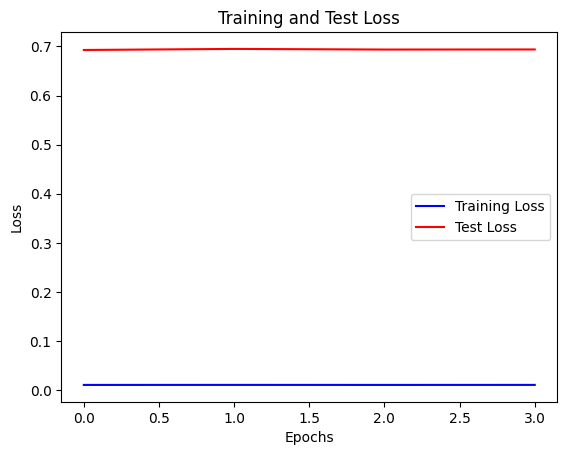

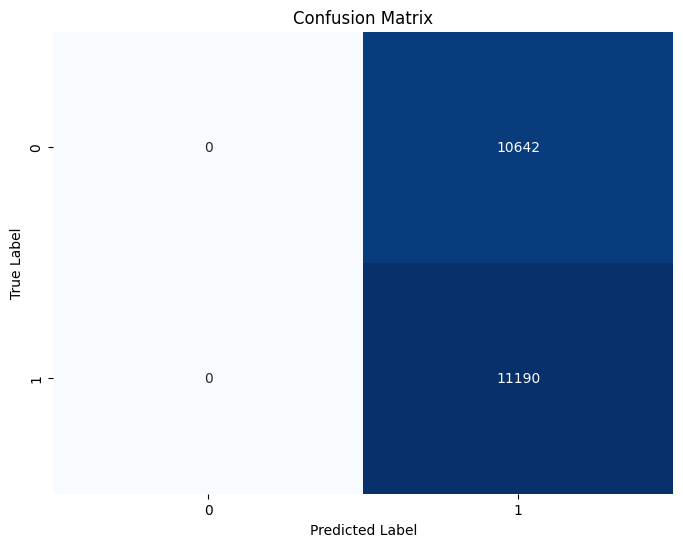

In [16]:
#Classificatoon run 1
#for additional data
best_params={'learning_rate': 3.936203985094611e-05, 'batch_size': 79, 'weight_decay': 0.00023645270928788307}


from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)

import torch
import psutil
import time
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.cuda.amp as amp

GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs

# Clear GPU cache memory
#torch.cuda.empty_cache()

# System and GPU Monitoring Functions
def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

# Evaluate Model Function
def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

# Hyperparameters and Training Setup
# best_params = study.best_params
learning_rate = best_params["learning_rate"]
#batch_size = best_params["batch_size"] * 2
#batch_size = 52
num_epochs = 10
model = CustomBERTModel(num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(X_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
scaler = amp.GradScaler()
train_losses = []
test_losses = []  # Storing test losses

# Early stopping parameters
patience = 3
best_test_acc = 0.0
epochs_without_improvement = 0

# Training Loop with Gradient Accumulation
model.train()
start_time = time.time()

# Additional variables for gradient accumulation
accumulated_loss = 0.0
gradient_step_counter = 0  # To keep track of when to perform an optimization step

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    running_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        
        with amp.autocast():
            outputs = model(inputs)
            labels = labels.long()
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
        
        # Change from immediate backward pass to accumulating gradients
        scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
        accumulated_loss += loss.item()

        # Perform an optimization step once every GRADIENT_ACCUMULATION_STEPS
        gradient_step_counter += 1
        if gradient_step_counter % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            running_loss += accumulated_loss  # We add the accumulated loss here
            accumulated_loss = 0.0
    
    train_loss = running_loss / len(X_dataset)
    train_losses.append(train_loss)

    # Evaluate on test set after each epoch
    test_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    test_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader, criterion)
    test_losses.append(test_loss)  # Storing test loss

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    # Early stopping logic
    if acc > best_test_acc:
        best_test_acc = acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "class_best_model.pth")
        # Saving model weights after training
        torch.save(model.bert_model.state_dict(), "class_bert_model_weights.pth")
        torch.save(model.xlm_roberta_model.state_dict(), "class_xlm_roberta_model_weights.pth")
        torch.save(model.distilbert_model.state_dict(), "class_distilbert_model_weights.pth")
        #torch.save(model.bertje_model.state_dict(), "bertje_model_weights.pth")
        #torch.save(model.roberta_model.state_dict(), "roberta_model_weights.pth")
        #torch.save(model.bertdutch_model.state_dict(), "bertdutch_model_weights.pth")
        #torch.save(model.bertnl_model.state_dict(), "bertnl_model_weights.pth") 
     
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == patience:
            print("Early stopping due to no improvement!")
            break

    epoch_duration = time.time() - epoch_start_time
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_time_left = epoch_duration * remaining_epochs
    print(f"Estimated time left for training: {estimated_time_left:.2f} seconds")

    ram_percent, cpu_percent = get_system_usage()
    gpu_memory = get_gpu_memory()
    print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

# Load Best Model
loaded_model = CustomBERTModel(num_labels=2).to(device)
loaded_model.load_state_dict(torch.load("class_best_model.pth"))
loaded_model.eval()

# Evaluate Best Model
f1, acc, precision, recall, true_labels, preds = evaluate_model(loaded_model, test_loader, criterion)[-6:]

print(f"Best Model Performance - Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Plot Training and Test Loss
plt.plot(train_losses, label="Training Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [25]:
class CombinedModel(nn.Module):
    def __init__(self, num_labels):
        super(CombinedModel, self).__init__()

        # Load the pretrained BERT model and its weights
        self.pretrained_bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels)
        self.pretrained_bert_model.load_state_dict(torch.load("class_bert_model_weights.pth"))
        for param in self.pretrained_bert_model.parameters():
            param.requires_grad = False

        # Load the pretrained XLM-Roberta model and its weights
        self.pretrained_xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels)
        self.pretrained_xlm_roberta_model.load_state_dict(torch.load("class_xlm_roberta_model_weights.pth"))
        for param in self.pretrained_xlm_roberta_model.parameters():
            param.requires_grad = False
            
        # Load the pretrained DistilBERT model and its weights
        self.pretrained_distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels)
        self.pretrained_distilbert_model.load_state_dict(torch.load("class_distilbert_model_weights.pth"))
        for param in self.pretrained_distilbert_model.parameters():
            param.requires_grad = False


        # Fresh BERT model
        self.bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        self.bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels)

        # Fresh XLM-Roberta model
        self.xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
        self.xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels)

        # Fresh DistilBERT model
        self.distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
        self.distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels)

        # Dropout layer
        self.dropout = nn.Dropout(0.3)

        # Combined output size from all models (768 size for each model's output)
        combined_output_size = num_labels * 6  # 6 because 3 pretrained and 3 fresh models
        
        # Deep dense layers for soft voting mechanism
        self.fc1 = nn.Linear(combined_output_size , 1024)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(512, num_labels)
        self.relu = nn.ReLU()

    def forward(self, input_ids):
        # Getting pretrained logits
        pretrained_bert_logits = self.pretrained_bert_model(input_ids).logits
        pretrained_xlm_roberta_logits = self.pretrained_xlm_roberta_model(input_ids).logits
        pretrained_distilbert_logits = self.pretrained_distilbert_model(input_ids).logits
        
        # Getting logits from fresh models
        bert_logits = self.bert_model(input_ids).logits
        xlm_roberta_logits = self.xlm_roberta_model(input_ids).logits
        distilbert_logits = self.distilbert_model(input_ids).logits

        # Convert logits to softmax probabilities
        pretrained_bert_probs = F.softmax(pretrained_bert_logits, dim=1)
        pretrained_xlm_roberta_probs = F.softmax(pretrained_xlm_roberta_logits, dim=1)
        pretrained_distilbert_probs = F.softmax(pretrained_distilbert_logits, dim=1)
        
        bert_probs = F.softmax(bert_logits, dim=1)
        xlm_roberta_probs = F.softmax(xlm_roberta_logits, dim=1)
        distilbert_probs = F.softmax(distilbert_logits, dim=1)

        # Concatenate probabilities
        concatenated = torch.cat((bert_probs, xlm_roberta_probs, distilbert_probs, 
                                  pretrained_bert_probs, pretrained_xlm_roberta_probs, pretrained_distilbert_probs), dim=1)
        concatenated = self.dropout(concatenated)
        
        # Pass through the deep dense layers
        out = self.fc1(concatenated)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)

        return out

In [19]:
GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs

def objective(trial):
    
    # Get data for a specific fold - assuming trial.number returns current trial number
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = split_data_for_fold(trial.number % 5)  # Here we assumed 5 folds

    # Tokenization
    tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
    train_encodings_fold = tokenizer(X_train_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    test_encodings_fold = tokenizer(X_test_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    
    # Hyperparameters 
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_int("batch_size", 64, 128, log=True)
    num_epochs = 3

    # Model, optimizer, criterion
    model = CombinedModel(num_labels=2).to(device)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)  # Hyperparameter search for weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # Adding weight decay here
    #optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    #criterion = nn.CrossEntropyLoss()
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Creating the datasets
    train_dataset_fold = CustomDataset(train_encodings_fold, y_train_fold)
    test_dataset_fold = CustomDataset(test_encodings_fold, y_test_fold)
    
    # DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    # Use this test_loader if needed in validation
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # DataLoader
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for batch_idx, batch in enumerate(train_loader_fold):
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and gradient accumulation
            loss.backward()
            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
                
            running_loss += loss.item()
            
            # Clean up
            del inputs, labels, outputs
            torch.cuda.empty_cache()
            
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        # Estimation of finishing time
        remaining_epochs = num_epochs - (epoch + 1)
        estimated_time_left = epoch_duration * remaining_epochs
        print(f"Epoch {epoch + 1}/{num_epochs} - Estimated time left for training: {estimated_time_left:.2f} seconds")

        # Monitor RAM, CPU, and GPU usage
        ram_percent, cpu_percent = get_system_usage()
        gpu_memory = get_gpu_memory()
        print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Total training time: {training_time:.2f} seconds")
    
    # Evaluate the model
    #f1, acc, precision, recall, true_labels, preds  = evaluate_model(model, test_loader_fold, criterion)
    average_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader_fold, criterion)

    print(f"F1 Score (Macro): {f1:.4f}, Accuracy: {acc:.4f}, Precision (Macro): {precision:.4f}, Recall (Macro): {recall:.4f}")

    return f1  # Return F1-score for Optuna optimization. Adjust if needed.

study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=3)
study.optimize(objective, n_trials=15)  # For instance, if using 5 folds, you can do 3 trials for each fold, totaling 15 trials.

all_f1_scores = [trial.value for trial in study.trials]
average_f1_score = sum(all_f1_scores) / len(all_f1_scores)
print(f"Average F1 Score (Macro) over {len(all_f1_scores)} folds: {average_f1_score:.4f}")

print(study.best_params)

[I 2023-09-04 00:44:11,796] A new study created in memory with name: no-name-15f18bb9-d267-49c6-95d3-888be5fd1453
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.bias', 'classi

Epoch 1/3 - Estimated time left for training: 476.52 seconds
RAM Usage: 7.6%, CPU Usage: 12.2%, GPU Memory Used: 9.497491968 GB
Epoch 2/3 - Estimated time left for training: 237.72 seconds
RAM Usage: 7.6%, CPU Usage: 14.8%, GPU Memory Used: 9.497491968 GB
Epoch 3/3 - Estimated time left for training: 0.00 seconds
RAM Usage: 7.6%, CPU Usage: 14.9%, GPU Memory Used: 9.497491968 GB
Total training time: 713.57 seconds


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-04 00:57:08,147] Trial 0 finished with value: 0.3333333333333333 and parameters: {'learning_rate': 0.0006190052326515285, 'batch_size': 110, 'weight_decay': 0.00030198966026527774}. Best is trial 0 with value: 0.3333333333333333.


F1 Score (Macro): 0.3333, Accuracy: 0.5000, Precision (Macro): 0.2500, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.bias', 'classifier.weight', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to us

...

Epoch 1/3 - Estimated time left for training: 496.76 seconds
RAM Usage: 8.7%, CPU Usage: 15.4%, GPU Memory Used: 9.505947136 GB
Epoch 2/3 - Estimated time left for training: 248.52 seconds
RAM Usage: 8.7%, CPU Usage: 13.8%, GPU Memory Used: 9.505947136 GB
Epoch 3/3 - Estimated time left for training: 0.00 seconds
RAM Usage: 8.7%, CPU Usage: 14.2%, GPU Memory Used: 9.505947136 GB
Total training time: 745.08 seconds


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-04 01:37:33,959] Trial 3 finished with value: 0.3332062523827678 and parameters: {'learning_rate': 0.00010303816814801621, 'batch_size': 73, 'weight_decay': 9.292856560214555e-05}. Best is trial 0 with value: 0.3333333333333333.


F1 Score (Macro): 0.3332, Accuracy: 0.4997, Precision (Macro): 0.2499, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'pre_classifier.bias', 'classifier.weight', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to us

OutOfMemoryError: CUDA out of memory. Tried to allocate 382.00 MiB (GPU 0; 79.32 GiB total capacity; 77.32 GiB already allocated; 219.56 MiB free; 77.71 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/tmp/ipykernel_156/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_156/4084739685.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipykernel_156/4084739685.py:43: UserWarning: To copy construct from a tenso

Epoch [4/10], Train Loss: 0.0134, Test Loss: 0.6933, Test Accuracy: 0.4874
Early stopping due to no improvement!


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to us

Best Model Performance - Accuracy: 0.4874
F1 Score: 0.3277
Precision: 0.2437
Recall: 0.5000


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


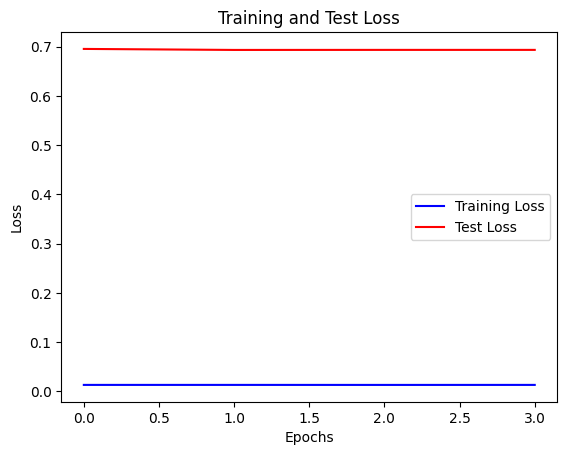

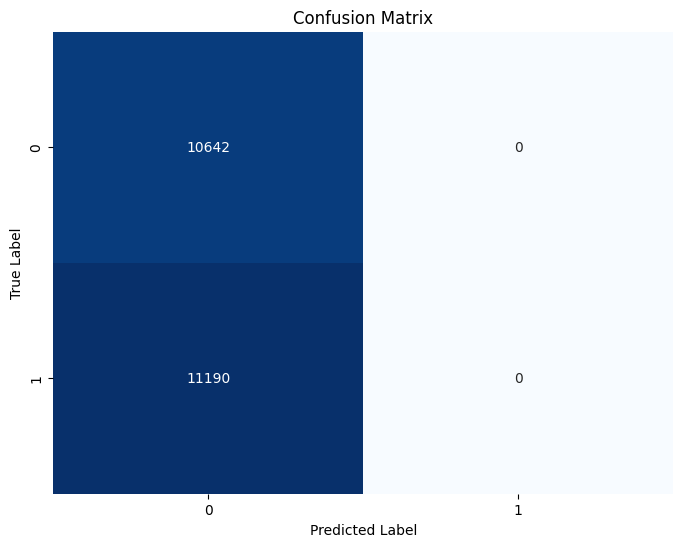

In [20]:
import torch
import psutil
import time
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.cuda.amp as amp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#best_params = {'learning_rate': 5.1861920141671966e-05, 'batch_size': 102, 'weight_decay': 3.615286714186411e-05}
best_params = {'learning_rate': 0.0006190052326515285, 'batch_size': 110, 'weight_decay': 0.00030198966026527774}
GRADIENT_ACCUMULATION_STEPS = 2  

def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

learning_rate = best_params["learning_rate"]
batch_size = 52
num_epochs = 10
model = CombinedModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(X_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
scaler = amp.GradScaler()

train_losses = []
test_losses = []

patience = 3
best_test_acc = 0.0
epochs_without_improvement = 0

model.train()
start_time = time.time()

accumulated_loss = 0.0
gradient_step_counter = 0

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    running_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        
        with amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
        accumulated_loss += loss.item()
        gradient_step_counter += 1
        if gradient_step_counter % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            running_loss += accumulated_loss
            accumulated_loss = 0.0
    
    train_loss = running_loss / len(X_dataset)
    train_losses.append(train_loss)

    test_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    test_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader, criterion)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    if acc > best_test_acc:
        best_test_acc = acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "class_combined_model_weights.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == patience:
            print("Early stopping due to no improvement!")
            break

    epoch_duration = time.time() - epoch_start_time
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_time_left = epoch_duration * remaining_epochs
    print(f"Estimated time left for training: {estimated_time_left:.2f} seconds")

    ram_percent, cpu_percent = get_system_usage()
    gpu_memory = get_gpu_memory()
    print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

# Load Best Model
loaded_model = CombinedModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
loaded_model.load_state_dict(torch.load("class_combined_model_weights.pth"))
loaded_model.eval()

f1, acc, precision, recall, true_labels, preds = evaluate_model(loaded_model, test_loader, criterion)[-6:]

print(f"Best Model Performance - Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Plot Training and Test Loss
plt.plot(train_losses, label="Training Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [26]:
#Only train on main data

In [18]:
GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

def objective(trial):
    
    # Get data for a specific fold - assuming trial.number returns current trial number
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = split_data_for_fold(trial.number % 5)  # Here we assumed 5 folds

    # Tokenization
    tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
    train_encodings_fold = tokenizer(X_train_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    test_encodings_fold = tokenizer(X_test_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    
    # Hyperparameters 
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_int("batch_size", 64, 128, log=True)
    num_epochs = 3

    # Model, optimizer, criterion
    model = CustomBERTModel(num_labels=2).to(device)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)  # Hyperparameter search for weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # Adding weight decay here
    #optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    #criterion = nn.CrossEntropyLoss()
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Creating the datasets
    train_dataset_fold = CustomDataset(train_encodings_fold, y_train_fold)
    test_dataset_fold = CustomDataset(test_encodings_fold, y_test_fold)
    
    # DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    # Use this test_loader if needed in validation
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # DataLoader
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for batch_idx, batch in enumerate(train_loader_fold):
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and gradient accumulation
            loss.backward()
            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
                
            running_loss += loss.item()
            
            # Clean up
            del inputs, labels, outputs
            torch.cuda.empty_cache()
            
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        # Estimation of finishing time
        remaining_epochs = num_epochs - (epoch + 1)
        estimated_time_left = epoch_duration * remaining_epochs
        print(f"Epoch {epoch + 1}/{num_epochs} - Estimated time left for training: {estimated_time_left:.2f} seconds")

        # Monitor RAM, CPU, and GPU usage
        ram_percent, cpu_percent = get_system_usage()
        gpu_memory = get_gpu_memory()
        print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Total training time: {training_time:.2f} seconds")
    
    # Evaluate the model
    #f1, acc, precision, recall, true_labels, preds  = evaluate_model(model, test_loader_fold, criterion)
    average_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader_fold, criterion)

    print(f"F1 Score (Macro): {f1:.4f}, Accuracy: {acc:.4f}, Precision (Macro): {precision:.4f}, Recall (Macro): {recall:.4f}")

    return f1  # Return F1-score for Optuna optimization. Adjust if needed.

study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=3)
study.optimize(objective, n_trials=15)  # For instance, if using 5 folds, you can do 3 trials for each fold, totaling 15 trials.

all_f1_scores = [trial.value for trial in study.trials]
average_f1_score = sum(all_f1_scores) / len(all_f1_scores)
print(f"Average F1 Score (Macro) over {len(all_f1_scores)} folds: {average_f1_score:.4f}")
 
print(study.best_params)

[I 2023-09-04 08:44:13,264] A new study created in memory with name: no-name-cc9a7f0e-cb30-470a-979f-68eb5312e6e7
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['pre_classifier.bias', 'classifier.bias', 'classi

Epoch 1/3 - Estimated time left for training: 458.96 seconds
RAM Usage: 8.0%, CPU Usage: 11.1%, GPU Memory Used: 16.59453184 GB
Epoch 2/3 - Estimated time left for training: 231.31 seconds
RAM Usage: 8.0%, CPU Usage: 15.0%, GPU Memory Used: 16.59453184 GB
Epoch 3/3 - Estimated time left for training: 0.00 seconds
RAM Usage: 8.0%, CPU Usage: 14.0%, GPU Memory Used: 16.59453184 GB
Total training time: 693.61 seconds


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-04 08:56:37,536] Trial 0 finished with value: 0.3333333333333333 and parameters: {'learning_rate': 0.00019638948795762788, 'batch_size': 100, 'weight_decay': 0.00018078528745386189}. Best is trial 0 with value: 0.3333333333333333.


F1 Score (Macro): 0.3333, Accuracy: 0.5000, Precision (Macro): 0.2500, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['pre_classifier.bias', 'classifier.bias', 'classifier.weight', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to us

...

F1 Score (Macro): 0.3335, Accuracy: 0.5003, Precision (Macro): 0.2501, Recall (Macro): 0.5000


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['pre_classifier.bias', 'classifier.bias', 'classifier.weight', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to us

Epoch 1/3 - Estimated time left for training: 353.10 seconds
RAM Usage: 8.0%, CPU Usage: 16.8%, GPU Memory Used: 18.96525056 GB


[W 2023-09-04 09:33:46,904] Trial 4 failed with parameters: {'learning_rate': 2.9418263423993612e-05, 'batch_size': 66, 'weight_decay': 0.00015664390174034348} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.9/dist-packages/optuna/study/_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_329/4024555724.py", line 83, in objective
    loss.backward()
  File "/usr/local/lib/python3.9/dist-packages/torch/_tensor.py", line 487, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.9/dist-packages/torch/autograd/__init__.py", line 200, in backward
    Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
KeyboardInterrupt
[W 2023-09-04 09:33:46,905] Trial 4 failed with value None.


KeyboardInterrupt: 

In [ ]:
#Voting system based on the class

In [24]:
import torch
import torch.nn as nn
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)
from torch.utils.data import DataLoader

# Assuming this is somewhere in your code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        
        # BERT (multilingual)
        self.bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        self.bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels)
        
        # XLM Roberta
        self.xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
        self.xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels)
        
        # DistilBERT
        self.distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
        self.distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels)

    def forward(self, input_ids):
    
        # Getting logits from each model
        bert_logits = self.bert_model(input_ids).logits
        xlm_roberta_logits = self.xlm_roberta_model(input_ids).logits
        distilbert_logits = self.distilbert_model(input_ids).logits

        # Getting predictions from logits
        _, bert_preds = torch.max(bert_logits, dim=1)
        _, xlm_roberta_preds = torch.max(xlm_roberta_logits, dim=1)
        _, distilbert_preds = torch.max(distilbert_logits, dim=1)

        # Stacking predictions
        all_preds = torch.stack((bert_preds, xlm_roberta_preds, distilbert_preds), dim=0)
        # Voting mechanism
        final_preds, _ = torch.mode(all_preds, dim=0)

        return final_preds

In [25]:
GRADIENT_ACCUMULATION_STEPS = 2  # Define this according to your needs
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

def objective(trial):
    
    # Get data for a specific fold - assuming trial.number returns current trial number
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = split_data_for_fold(trial.number % 5)  # Here we assumed 5 folds

    # Tokenization
    tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
    train_encodings_fold = tokenizer(X_train_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    test_encodings_fold = tokenizer(X_test_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    
    # Hyperparameters 
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_int("batch_size", 64, 128, log=True)
    num_epochs = 3

    # Model, optimizer, criterion
    model = CustomBERTModel(num_labels=2).to(device)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)  # Hyperparameter search for weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)  # Adding weight decay here
    #optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    #criterion = nn.CrossEntropyLoss()
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Creating the datasets
    train_dataset_fold = CustomDataset(train_encodings_fold, y_train_fold)
    test_dataset_fold = CustomDataset(test_encodings_fold, y_test_fold)
    
    # DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    # Use this test_loader if needed in validation
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # DataLoader
    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for batch_idx, batch in enumerate(train_loader_fold):
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and gradient accumulation
            loss.backward()
            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
                
            running_loss += loss.item()
            
            # Clean up
            del inputs, labels, outputs
            torch.cuda.empty_cache()
            
        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time

        # Estimation of finishing time
        remaining_epochs = num_epochs - (epoch + 1)
        estimated_time_left = epoch_duration * remaining_epochs
        print(f"Epoch {epoch + 1}/{num_epochs} - Estimated time left for training: {estimated_time_left:.2f} seconds")

        # Monitor RAM, CPU, and GPU usage
        ram_percent, cpu_percent = get_system_usage()
        gpu_memory = get_gpu_memory()
        print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Total training time: {training_time:.2f} seconds")
    
    # Evaluate the model
    #f1, acc, precision, recall, true_labels, preds  = evaluate_model(model, test_loader_fold, criterion)
    average_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader_fold, criterion)

    print(f"F1 Score (Macro): {f1:.4f}, Accuracy: {acc:.4f}, Precision (Macro): {precision:.4f}, Recall (Macro): {recall:.4f}")

    return f1  # Return F1-score for Optuna optimization. Adjust if needed.

study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=3)
study.optimize(objective, n_trials=15)  # For instance, if using 5 folds, you can do 3 trials for each fold, totaling 15 trials.

all_f1_scores = [trial.value for trial in study.trials]
average_f1_score = sum(all_f1_scores) / len(all_f1_scores)
print(f"Average F1 Score (Macro) over {len(all_f1_scores)} folds: {average_f1_score:.4f}")
 
print(study.best_params)

[I 2023-09-04 09:57:17,545] A new study created in memory with name: no-name-dd475a53-1669-44c0-b111-2c4123a2d143
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_clas

RuntimeError: Expected floating point type for target with class probabilities, got Long

In [ ]:
import time
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)
from torch.utils.data import DataLoader

# Assuming this is somewhere in your code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()

        # Load and move to the correct device directly here
        self.bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        self.bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels).to(device)
        
        self.xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
        self.xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels).to(device)
        
        self.distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
        self.distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels).to(device)

    def forward(self, input_ids):
        # Return stacked logits
        bert_logits = self.bert_model(input_ids).logits
        xlm_roberta_logits = self.xlm_roberta_model(input_ids).logits
        distilbert_logits = self.distilbert_model(input_ids).logits

        all_logits = torch.stack((bert_logits, xlm_roberta_logits, distilbert_logits), dim=0)
        return all_logits

GRADIENT_ACCUMULATION_STEPS = 2

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            logits = model(inputs)
            final_logits, _ = torch.mode(logits, dim=0)  # Voting mechanism
            loss = criterion(final_logits, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(final_logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())

    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')

    return average_loss, f1, acc, precision, recall, true_labels, predictions

def objective(trial):
    # Assuming the implementation exists for split_data_for_fold
    X_train_fold, X_test_fold, y_train_fold, y_test_fold = split_data_for_fold(trial.number % 5)

    tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-uncased')
    train_encodings_fold = tokenizer(X_train_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")
    test_encodings_fold = tokenizer(X_test_fold['text'].astype(str).tolist(), truncation=True, padding='max_length', max_length=256, return_tensors="pt")

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_int("batch_size", 64, 128, log=True)
    num_epochs = 3

    model = CustomBERTModel(num_labels=2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Assuming class_weights is available
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Assuming the implementation exists for CustomDataset
    train_dataset_fold = CustomDataset(train_encodings_fold, y_train_fold)
    test_dataset_fold = CustomDataset(test_encodings_fold, y_test_fold)

    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_idx, batch in enumerate(train_loader_fold):
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            final_logits, _ = torch.mode(logits, dim=0)  # Voting mechanism
            loss = criterion(final_logits, labels)

            loss.backward()

            # Adjusting for gradient accumulation
            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                for param in model.parameters():
                    param.grad /= GRADIENT_ACCUMULATION_STEPS
                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item()

            # Clean up
            del inputs, labels, logits
            torch.cuda.empty_cache()

        # Assuming the implementations exist for get_system_usage and get_gpu_memory
        ram_percent, cpu_percent = get_system_usage()
        gpu_memory = get_gpu_memory()
        print(f"Epoch {epoch + 1}/{num_epochs}, RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

    average_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader_fold, criterion)

    print(f"F1 Score (Macro): {f1:.4f}, Accuracy: {acc:.4f}, Precision (Macro): {precision:.4f}, Recall (Macro): {recall:.4f}")
    print(f"Time taken: {(time.time() - start_time) / 60:.2f} mins")

    return f1

# Set up the Optuna study here
# study = optuna.create_study(...)
# study.optimize(objective, n_trials=100)

study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=3)
study.optimize(objective, n_trials=15)  # For instance, if using 5 folds, you can do 3 trials for each fold, totaling 15 trials.

all_f1_scores = [trial.value for trial in study.trials]
average_f1_score = sum(all_f1_scores) / len(all_f1_scores)
print(f"Average F1 Score (Macro) over {len(all_f1_scores)} folds: {average_f1_score:.4f}")
 
print(study.best_params)

[I 2023-09-04 10:05:18,581] A new study created in memory with name: no-name-362fa057-c6b8-416f-9a37-3d764b1b5655
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_clas

Epoch 1/3, RAM Usage: 9.5%, CPU Usage: 9.5%, GPU Memory Used: 17.482962944 GB
Epoch 2/3, RAM Usage: 9.5%, CPU Usage: 14.5%, GPU Memory Used: 17.482962944 GB
Epoch 3/3, RAM Usage: 9.5%, CPU Usage: 14.7%, GPU Memory Used: 17.482962944 GB


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
[I 2023-09-04 10:16:25,795] Trial 0 finished with value: 0.3333333333333333 and parameters: {'learning_rate': 0.00021316224658864791, 'batch_size': 91, 'weight_decay': 2.136636629484269e-05}. Best is trial 0 with value: 0.3333333333333333.


F1 Score (Macro): 0.3333, Accuracy: 0.5000, Precision (Macro): 0.2500, Recall (Macro): 0.5000
Time taken: 10.60 mins


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to us

...

Epoch 1/3, RAM Usage: 9.2%, CPU Usage: 16.9%, GPU Memory Used: 9.489424384 GB
Epoch 2/3, RAM Usage: 9.2%, CPU Usage: 15.6%, GPU Memory Used: 9.489424384 GB
Epoch 3/3, RAM Usage: 9.2%, CPU Usage: 15.9%, GPU Memory Used: 9.489424384 GB


[I 2023-09-04 10:35:45,167] Trial 2 finished with value: 0.5078828560333218 and parameters: {'learning_rate': 5.8185984225274366e-05, 'batch_size': 82, 'weight_decay': 0.00010044708684290703}. Best is trial 1 with value: 0.8873090177955323.


F1 Score (Macro): 0.5079, Accuracy: 0.5080, Precision (Macro): 0.5080, Recall (Macro): 0.5080
Time taken: 9.33 mins


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to us

Epoch 1/3, RAM Usage: 9.0%, CPU Usage: 15.5%, GPU Memory Used: 9.483441664 GB


In [21]:
import time
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from transformers import (BertTokenizer, BertForSequenceClassification,
                          XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)
from torch.utils.data import DataLoader

# Assuming this is somewhere in your code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()

        # Load and move to the correct device directly here
        self.bert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        self.bert_model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_labels).to(device)
        
        self.xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
        self.xlm_roberta_model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=num_labels).to(device)
        
        self.distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')
        self.distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased', num_labels=num_labels).to(device)

    def forward(self, input_ids):
        # Return stacked logits
        bert_logits = self.bert_model(input_ids).logits
        xlm_roberta_logits = self.xlm_roberta_model(input_ids).logits
        distilbert_logits = self.distilbert_model(input_ids).logits

        all_logits = torch.stack((bert_logits, xlm_roberta_logits, distilbert_logits), dim=0)
        return all_logits

GRADIENT_ACCUMULATION_STEPS = 2

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            logits = model(inputs)
            final_logits, _ = torch.mode(logits, dim=0)  # Voting mechanism
            loss = criterion(final_logits, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(final_logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())

    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')

    return average_loss, f1, acc, precision, recall, true_labels, predictions

In [ ]:
import torch
import psutil
import time
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import torch.cuda.amp as amp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#best_params = {'learning_rate': 5.1861920141671966e-05, 'batch_size': 102, 'weight_decay': 3.615286714186411e-05}
best_params = {'learning_rate': 0.0006190052326515285, 'batch_size': 110, 'weight_decay': 0.00030198966026527774}
best_params = {'learning_rate': 6.871835594398317e-05, 'batch_size': 66, 'weight_decay': 0.000152125727160186}
GRADIENT_ACCUMULATION_STEPS = 2  

def get_system_usage():
    ram_percent = psutil.virtual_memory().percent
    cpu_percent = psutil.cpu_percent()
    return ram_percent, cpu_percent

def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated(device) / 1e9  # GBs
    return 0

def evaluate_model(model, loader, criterion):
    model.eval()
    true_labels = []
    predictions = []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
    
    average_loss = total_loss / len(loader.dataset)
    f1 = f1_score(true_labels, predictions, average='macro')
    acc = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    
    return average_loss, f1, acc, precision, recall, true_labels, predictions

learning_rate = best_params["learning_rate"]
#batch_size = 52
num_epochs = 10
model = CustomBERTModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
train_loader = DataLoader(X_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
scaler = amp.GradScaler()

train_losses = []
test_losses = []

patience = 3
best_test_acc = 0.0
epochs_without_improvement = 0

model.train()
start_time = time.time()

accumulated_loss = 0.0
gradient_step_counter = 0

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    running_loss = 0.0
    for batch_idx, batch in enumerate(train_loader):
        inputs = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        
        with amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss / GRADIENT_ACCUMULATION_STEPS).backward()
        accumulated_loss += loss.item()
        gradient_step_counter += 1
        if gradient_step_counter % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            running_loss += accumulated_loss
            accumulated_loss = 0.0
    
    train_loss = running_loss / len(X_dataset)
    train_losses.append(train_loss)

    test_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
    test_loss, f1, acc, precision, recall, true_labels, preds = evaluate_model(model, test_loader, criterion)
    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}")

    if acc > best_test_acc:
        best_test_acc = acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "class_combined_model_weights.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == patience:
            print("Early stopping due to no improvement!")
            break

    epoch_duration = time.time() - epoch_start_time
    remaining_epochs = num_epochs - (epoch + 1)
    estimated_time_left = epoch_duration * remaining_epochs
    print(f"Estimated time left for training: {estimated_time_left:.2f} seconds")

    ram_percent, cpu_percent = get_system_usage()
    gpu_memory = get_gpu_memory()
    print(f"RAM Usage: {ram_percent}%, CPU Usage: {cpu_percent}%, GPU Memory Used: {gpu_memory} GB")

# Load Best Model
loaded_model = CombinedModel(num_labels=2).to(device)  # Make sure CombinedModel is your model's name
loaded_model.load_state_dict(torch.load("class_combined_model_weights.pth"))
loaded_model.eval()

f1, acc, precision, recall, true_labels, preds = evaluate_model(loaded_model, test_loader, criterion)[-6:]

print(f"Best Model Performance - Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Plot Training and Test Loss
plt.plot(train_losses, label="Training Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()